## Example 1: Model Overfitting vs. Underfitting – Models Prone to Underfitting

Some machine learning models are more prone to underfitting than others. Examples of models that often underfit include Linear Regression, Linear Discriminant Analysis (LDA), and Logistic Regression. As suggested by their names, these linear models are generally simple and may fail to capture complex patterns in the data, leading to underfitting.

However, this is not always the case. Linear models can also overfit, especially when the number of features is greater than the number of training instances.

The figure below illustrates the difference between a Linear Regression model, which tends to underfit, and a high-order Polynomial Regression model, which may overfit, using Python code.


##  Understanding Overfitting and Underfitting

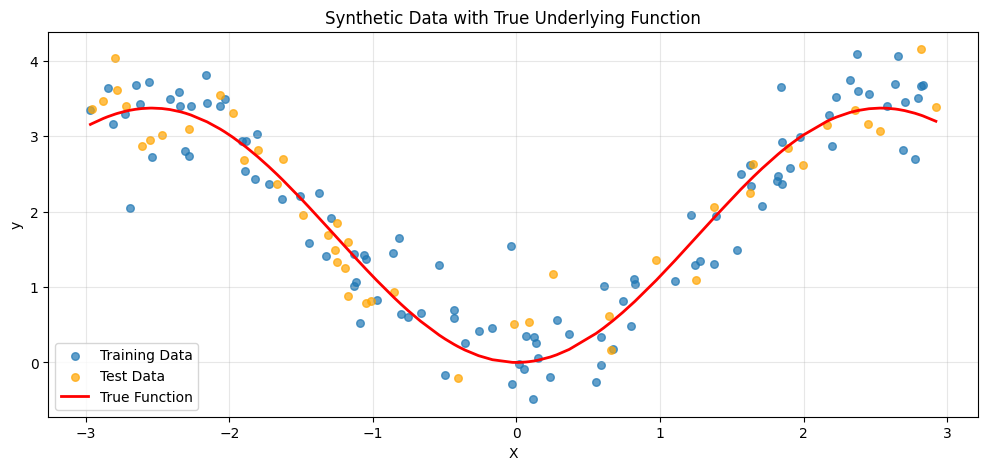

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data with noise
def generate_data(n_samples=100, noise_std=0.5):
    X = np.random.uniform(-3, 3, n_samples).reshape(-1, 1)
    # True function: f(x) = x * sin(x) + 0.5 * x^2
    y_true = X.flatten() * np.sin(X.flatten()) + 0.3 * X.flatten()**2
    y = y_true + np.random.normal(0, noise_std, n_samples)
    return X, y, y_true

X, y, y_true = generate_data(n_samples=150, noise_std=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualize the data
plt.figure(figsize=(12, 5))
plt.scatter(X_train, y_train, alpha=0.7, label='Training Data', s=30)
plt.scatter(X_test, y_test, alpha=0.7, label='Test Data', s=30, color='orange')
X_sorted = np.sort(X.flatten())
plt.plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
         color='red', label='True Function', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data with True Underlying Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Demonstrating Underfitting (High Bias)

UNDERFITTING EXAMPLE: LINEAR REGRESSION
Training MSE: 1.6976
Test MSE: 1.3360
Training R²: 0.0002
Test R²: -0.0455

Diagnosis: HIGH BIAS (Underfitting)
- Both training and test errors are high
- Model is too simple to capture the underlying pattern


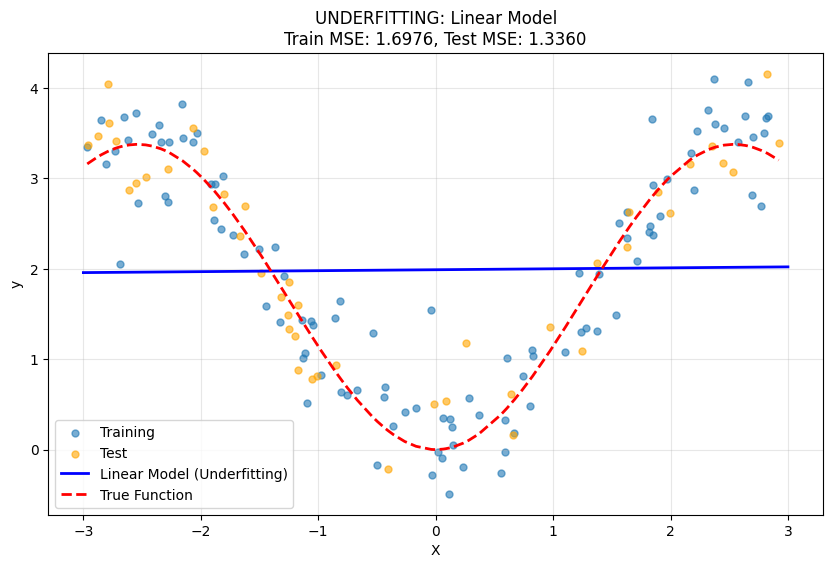

In [13]:
# Underfitting example: Linear model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

# Calculate errors
train_mse_linear = mean_squared_error(y_train, y_train_pred_linear)
test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)
train_r2_linear = r2_score(y_train, y_train_pred_linear)
test_r2_linear = r2_score(y_test, y_test_pred_linear)

print("="*60)
print("UNDERFITTING EXAMPLE: LINEAR REGRESSION")
print("="*60)
print(f"Training MSE: {train_mse_linear:.4f}")
print(f"Test MSE: {test_mse_linear:.4f}")
print(f"Training R²: {train_r2_linear:.4f}")
print(f"Test R²: {test_r2_linear:.4f}")
print("\nDiagnosis: HIGH BIAS (Underfitting)")
print("- Both training and test errors are high")
print("- Model is too simple to capture the underlying pattern")

# Plot underfitting
plt.figure(figsize=(10, 6))
X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
y_grid_pred = linear_model.predict(X_grid)

plt.scatter(X_train, y_train, alpha=0.6, label='Training', s=25)
plt.scatter(X_test, y_test, alpha=0.6, label='Test', s=25, color='orange')
plt.plot(X_grid, y_grid_pred, color='blue', linewidth=2, label='Linear Model (Underfitting)')
plt.plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
         color='red', label='True Function', linewidth=2, linestyle='--')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'UNDERFITTING: Linear Model\nTrain MSE: {train_mse_linear:.4f}, Test MSE: {test_mse_linear:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Demonstrating Overfitting (High Variance)

OVERFITTING EXAMPLE: POLYNOMIAL DEGREE 20
Training MSE: 0.1457
Test MSE: 0.6362
Training R²: 0.9142
Test R²: 0.5021

Diagnosis: HIGH VARIANCE (Overfitting)
- Training error is very low but test error is high
- Model is too complex and captures noise


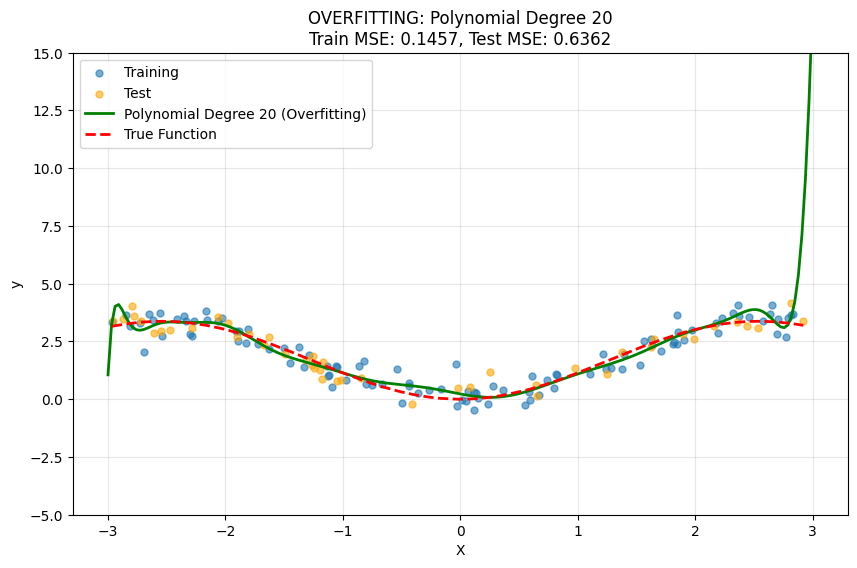

In [14]:
# Overfitting example: High-degree polynomial
overfit_model = make_pipeline(PolynomialFeatures(degree=20), LinearRegression())
overfit_model.fit(X_train, y_train)

# Predictions
y_train_pred_over = overfit_model.predict(X_train)
y_test_pred_over = overfit_model.predict(X_test)

train_mse_over = mean_squared_error(y_train, y_train_pred_over)
test_mse_over = mean_squared_error(y_test, y_test_pred_over)
train_r2_over = r2_score(y_train, y_train_pred_over)
test_r2_over = r2_score(y_test, y_test_pred_over)

print("="*60)
print("OVERFITTING EXAMPLE: POLYNOMIAL DEGREE 20")
print("="*60)
print(f"Training MSE: {train_mse_over:.4f}")
print(f"Test MSE: {test_mse_over:.4f}")
print(f"Training R²: {train_r2_over:.4f}")
print(f"Test R²: {test_r2_over:.4f}")
print("\nDiagnosis: HIGH VARIANCE (Overfitting)")
print("- Training error is very low but test error is high")
print("- Model is too complex and captures noise")

# Plot overfitting
plt.figure(figsize=(10, 6))
X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
y_grid_pred = overfit_model.predict(X_grid)

plt.scatter(X_train, y_train, alpha=0.6, label='Training', s=25)
plt.scatter(X_test, y_test, alpha=0.6, label='Test', s=25, color='orange')
plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Polynomial Degree 20 (Overfitting)')
plt.plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
         color='red', label='True Function', linewidth=2, linestyle='--')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'OVERFITTING: Polynomial Degree 20\nTrain MSE: {train_mse_over:.4f}, Test MSE: {test_mse_over:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-5, 15)
plt.show()

## Good Fit

GOOD FIT EXAMPLE: POLYNOMIAL DEGREE 3
Training MSE: 0.3636
Test MSE: 0.2695
Training R²: 0.7859
Test R²: 0.7891

Diagnosis: GOOD FIT
- Both training and test errors are low
- Model captures the underlying pattern without overfitting


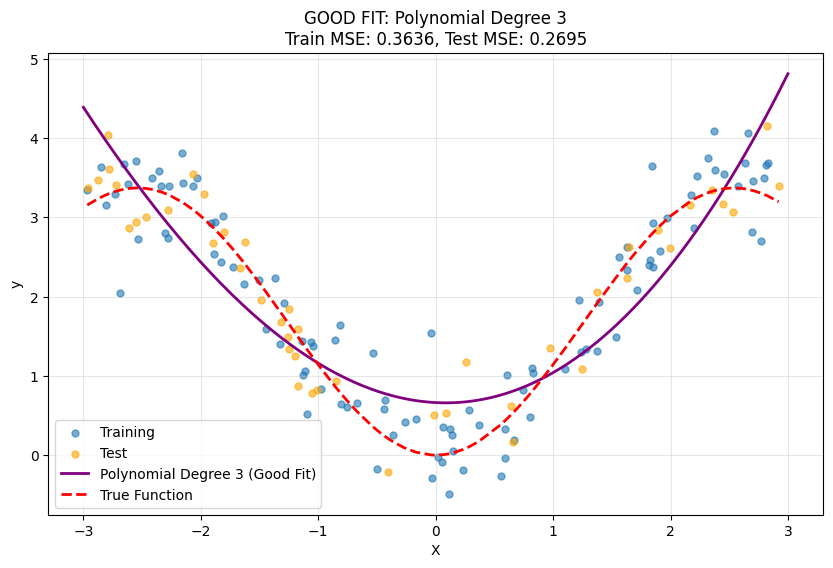

In [15]:
# Good fit example: Polynomial degree 3
good_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
good_model.fit(X_train, y_train)

# Predictions
y_train_pred_good = good_model.predict(X_train)
y_test_pred_good = good_model.predict(X_test)

train_mse_good = mean_squared_error(y_train, y_train_pred_good)
test_mse_good = mean_squared_error(y_test, y_test_pred_good)
train_r2_good = r2_score(y_train, y_train_pred_good)
test_r2_good = r2_score(y_test, y_test_pred_good)

print("="*60)
print("GOOD FIT EXAMPLE: POLYNOMIAL DEGREE 3")
print("="*60)
print(f"Training MSE: {train_mse_good:.4f}")
print(f"Test MSE: {test_mse_good:.4f}")
print(f"Training R²: {train_r2_good:.4f}")
print(f"Test R²: {test_r2_good:.4f}")
print("\nDiagnosis: GOOD FIT")
print("- Both training and test errors are low")
print("- Model captures the underlying pattern without overfitting")

# Plot good fit
plt.figure(figsize=(10, 6))
X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
y_grid_pred = good_model.predict(X_grid)

plt.scatter(X_train, y_train, alpha=0.6, label='Training', s=25)
plt.scatter(X_test, y_test, alpha=0.6, label='Test', s=25, color='orange')
plt.plot(X_grid, y_grid_pred, color='purple', linewidth=2, label='Polynomial Degree 3 (Good Fit)')
plt.plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
         color='red', label='True Function', linewidth=2, linestyle='--')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'GOOD FIT: Polynomial Degree 3\nTrain MSE: {train_mse_good:.4f}, Test MSE: {test_mse_good:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comparing All Models Side by Side

COMPARING POLYNOMIAL DEGREES: FROM UNDERFITTING TO OVERFITTING
Degree  1: Train MSE=1.6976, Test MSE=1.3360, Train R²=0.0002, Test R²=-0.0455
Degree  2: Train MSE=0.3675, Test MSE=0.2817, Train R²=0.7836, Test R²=0.7795
Degree  3: Train MSE=0.3636, Test MSE=0.2695, Train R²=0.7859, Test R²=0.7891
Degree  4: Train MSE=0.1677, Test MSE=0.1402, Train R²=0.9013, Test R²=0.8903
Degree  5: Train MSE=0.1654, Test MSE=0.1468, Train R²=0.9026, Test R²=0.8852
Degree  6: Train MSE=0.1652, Test MSE=0.1501, Train R²=0.9027, Test R²=0.8826
Degree  8: Train MSE=0.1603, Test MSE=0.1309, Train R²=0.9056, Test R²=0.8976
Degree 10: Train MSE=0.1573, Test MSE=0.1481, Train R²=0.9073, Test R²=0.8841
Degree 12: Train MSE=0.1522, Test MSE=0.1560, Train R²=0.9104, Test R²=0.8779
Degree 15: Train MSE=0.1486, Test MSE=0.5242, Train R²=0.9125, Test R²=0.5898
Degree 20: Train MSE=0.1457, Test MSE=0.6362, Train R²=0.9142, Test R²=0.5021

Optimal polynomial degree: 8
Minimum test MSE: 0.1309


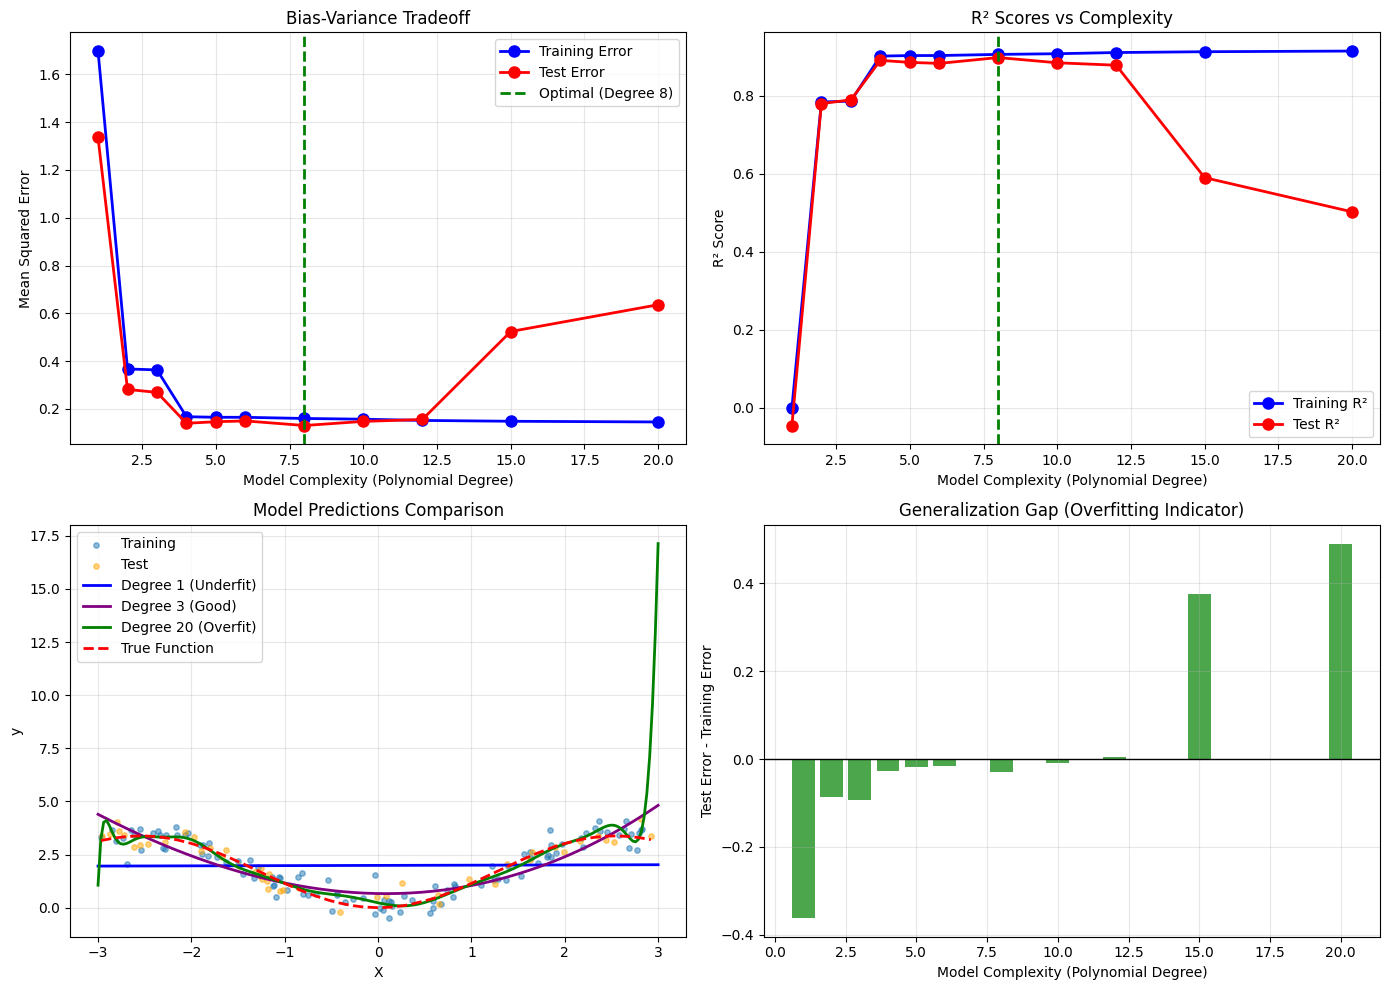

In [16]:
# Compare different polynomial degrees
degrees = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
train_errors = []
test_errors = []
train_r2_scores = []
test_r2_scores = []
models = []

print("="*80)
print("COMPARING POLYNOMIAL DEGREES: FROM UNDERFITTING TO OVERFITTING")
print("="*80)

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    models.append(model)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)
    
    print(f"Degree {degree:2d}: Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}, "
          f"Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")

# Find optimal degree
optimal_degree = degrees[np.argmin(test_errors)]
print(f"\nOptimal polynomial degree: {optimal_degree}")
print(f"Minimum test MSE: {min(test_errors):.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Learning curves (MSE vs complexity)
axes[0, 0].plot(degrees, train_errors, 'b-o', label='Training Error', linewidth=2, markersize=8)
axes[0, 0].plot(degrees, test_errors, 'r-o', label='Test Error', linewidth=2, markersize=8)
axes[0, 0].axvline(x=optimal_degree, color='green', linestyle='--', 
                   label=f'Optimal (Degree {optimal_degree})', linewidth=2)
axes[0, 0].set_xlabel('Model Complexity (Polynomial Degree)')
axes[0, 0].set_ylabel('Mean Squared Error')
axes[0, 0].set_title('Bias-Variance Tradeoff')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: R² scores
axes[0, 1].plot(degrees, train_r2_scores, 'b-o', label='Training R²', linewidth=2, markersize=8)
axes[0, 1].plot(degrees, test_r2_scores, 'r-o', label='Test R²', linewidth=2, markersize=8)
axes[0, 1].axvline(x=optimal_degree, color='green', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Model Complexity (Polynomial Degree)')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('R² Scores vs Complexity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Model predictions for selected degrees
selected_degrees = [1, 3, 20]
colors = ['blue', 'purple', 'green']
labels = ['Degree 1 (Underfit)', 'Degree 3 (Good)', 'Degree 20 (Overfit)']

axes[1, 0].scatter(X_train, y_train, alpha=0.5, label='Training', s=15)
axes[1, 0].scatter(X_test, y_test, alpha=0.5, label='Test', s=15, color='orange')
X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)

for deg, color, label in zip(selected_degrees, colors, labels):
    idx = degrees.index(deg)
    y_grid_pred = models[idx].predict(X_grid)
    axes[1, 0].plot(X_grid, y_grid_pred, color=color, linewidth=2, label=label)

axes[1, 0].plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
                color='red', label='True Function', linewidth=2, linestyle='--')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Model Predictions Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Gap between train and test error
gap = np.array(test_errors) - np.array(train_errors)
axes[1, 1].bar(degrees, gap, color=['green' if g < 0.5 else 'orange' if g < 1.0 else 'red' 
                                     for g in gap], alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Model Complexity (Polynomial Degree)')
axes[1, 1].set_ylabel('Test Error - Training Error')
axes[1, 1].set_title('Generalization Gap (Overfitting Indicator)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Learning Curves to Diagnose Overfitting/Underfitting


LEARNING CURVES FOR DIAGNOSIS

1. UNDERFITTING MODEL:


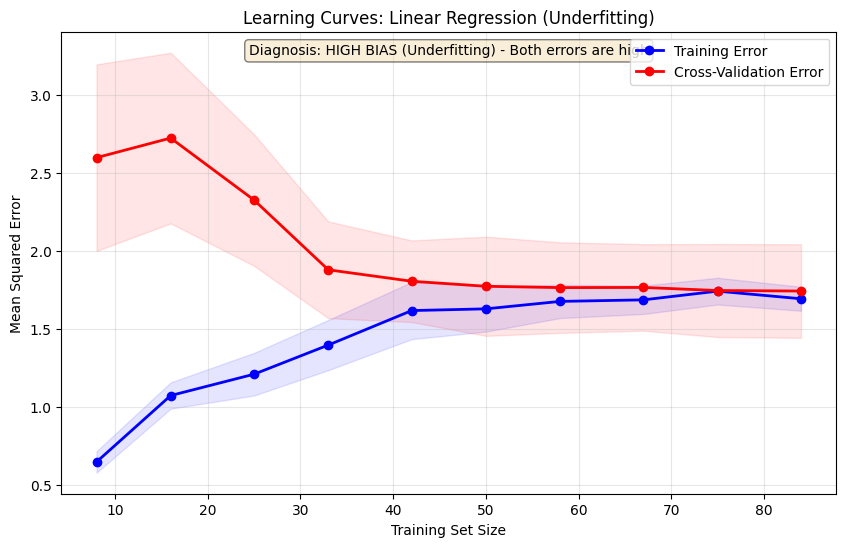


2. GOOD FIT MODEL:


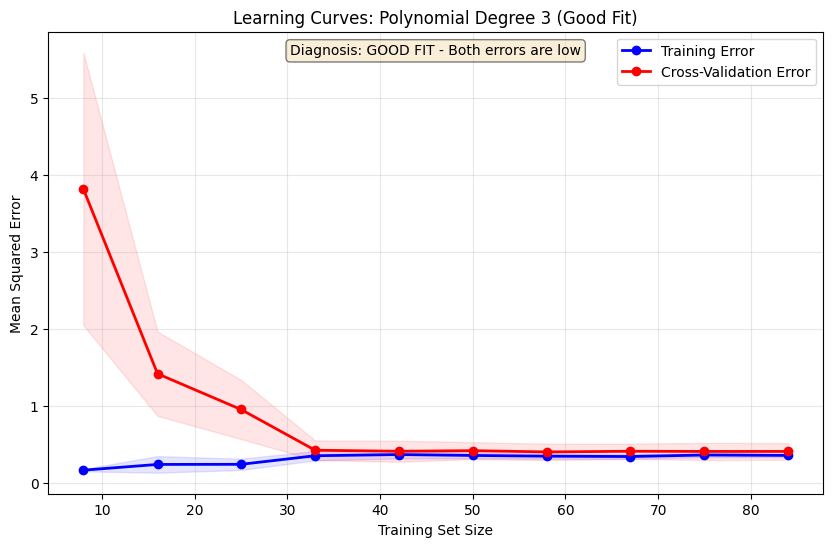


3. OVERFITTING MODEL:


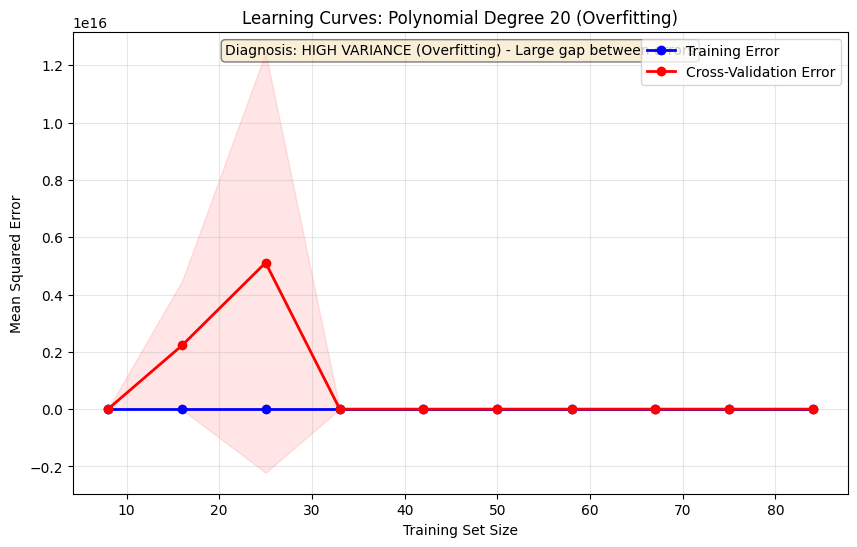

'HIGH VARIANCE (Overfitting) - Large gap between errors'

In [17]:
def plot_learning_curves(model, X, y, title, cv=5):
    """
    Plot learning curves to diagnose bias vs variance
    """
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error'
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='red')
    plt.plot(train_sizes, train_scores_mean, 'b-o', label='Training Error', linewidth=2)
    plt.plot(train_sizes, test_scores_mean, 'r-o', label='Cross-Validation Error', linewidth=2)
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Learning Curves: {title}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add diagnosis
    if train_scores_mean[-1] > 1.0 and test_scores_mean[-1] > 1.0:
        diagnosis = "HIGH BIAS (Underfitting) - Both errors are high"
    elif train_scores_mean[-1] < 0.5 and test_scores_mean[-1] > 1.0:
        diagnosis = "HIGH VARIANCE (Overfitting) - Large gap between errors"
    elif train_scores_mean[-1] < 0.5 and test_scores_mean[-1] < 0.5:
        diagnosis = "GOOD FIT - Both errors are low"
    else:
        diagnosis = "MODERATE - Need more data or regularization"
    
    plt.text(0.5, 0.95, f'Diagnosis: {diagnosis}', 
             transform=plt.gca().transAxes, ha='center', 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.show()
    
    return diagnosis

# Plot learning curves for different models
print("\n" + "="*60)
print("LEARNING CURVES FOR DIAGNOSIS")
print("="*60)

# Underfitting model (Linear)
print("\n1. UNDERFITTING MODEL:")
linear_model = LinearRegression()
plot_learning_curves(linear_model, X_train, y_train, 'Linear Regression (Underfitting)')

# Good model (Polynomial degree 3)
print("\n2. GOOD FIT MODEL:")
good_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
plot_learning_curves(good_model, X_train, y_train, 'Polynomial Degree 3 (Good Fit)')

# Overfitting model (Polynomial degree 20)
print("\n3. OVERFITTING MODEL:")
overfit_model = make_pipeline(PolynomialFeatures(20), LinearRegression())
plot_learning_curves(overfit_model, X_train, y_train, 'Polynomial Degree 20 (Overfitting)')

## Decision Trees: Underfitting vs Overfitting


DECISION TREE DEPTH COMPARISON
Depth    1: Train MSE=1.2401, Test MSE=1.1643, Train R²=0.2697, Test R²=0.0889
Depth    2: Train MSE=0.4459, Test MSE=0.3463, Train R²=0.7374, Test R²=0.7290
Depth    3: Train MSE=0.2596, Test MSE=0.2461, Train R²=0.8471, Test R²=0.8074
Depth    5: Train MSE=0.1020, Test MSE=0.1341, Train R²=0.9399, Test R²=0.8950
Depth   10: Train MSE=0.0354, Test MSE=0.1837, Train R²=0.9791, Test R²=0.8563
Depth   20: Train MSE=0.0354, Test MSE=0.1837, Train R²=0.9791, Test R²=0.8563
Depth None: Train MSE=0.0354, Test MSE=0.1837, Train R²=0.9791, Test R²=0.8563


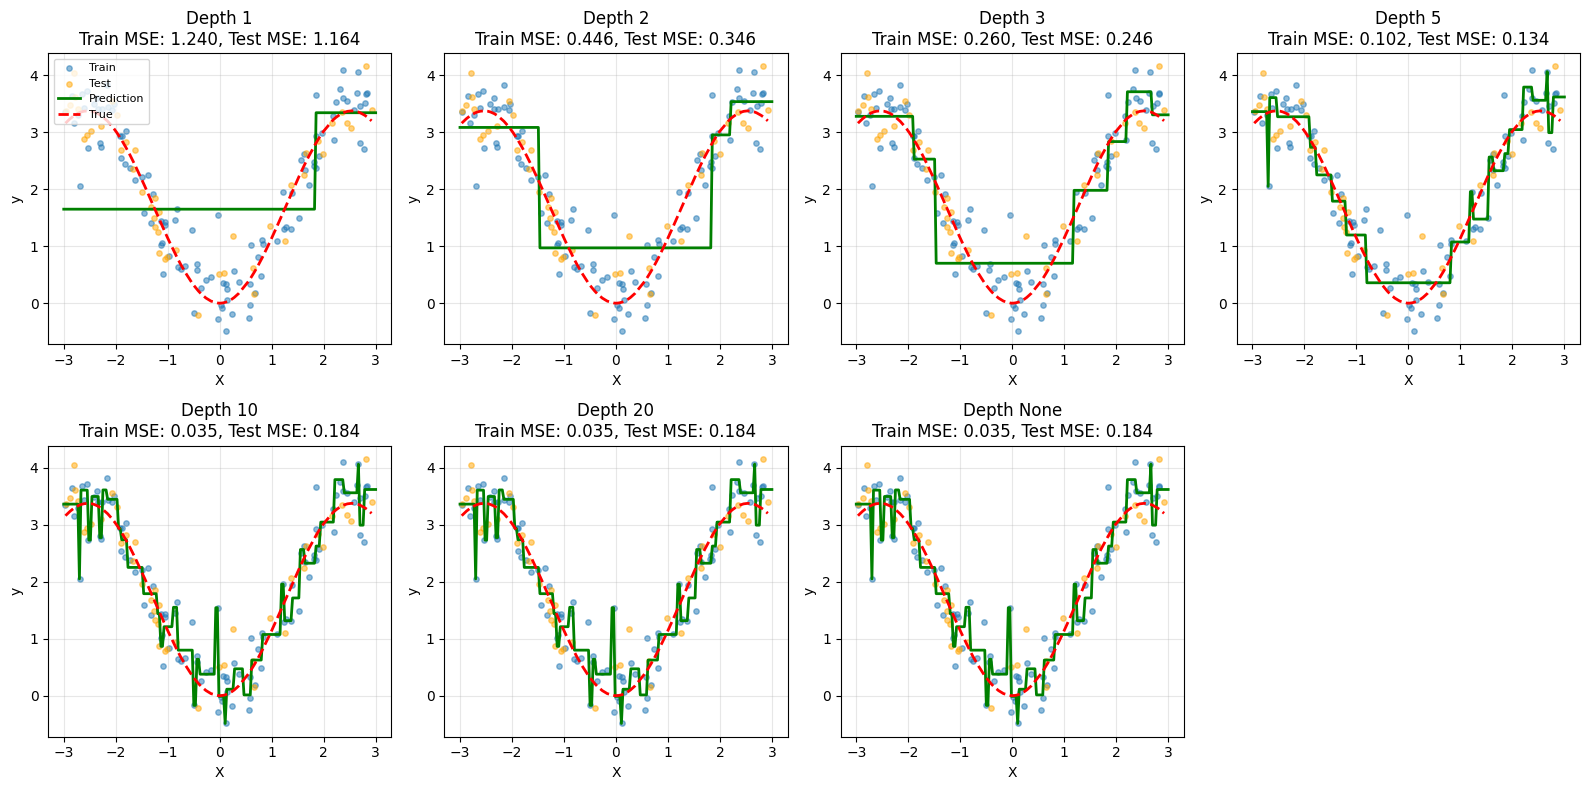

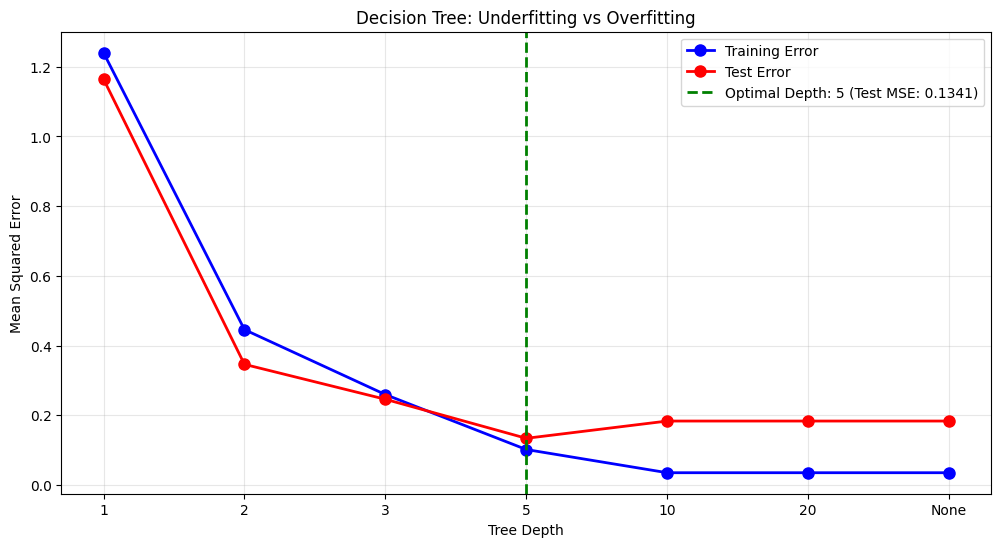


Optimal tree depth: 5
Minimum test error: 0.1341


In [18]:
# Decision trees with different depths - CORRECTED VERSION
depths = [1, 2, 3, 5, 10, 20, None]
tree_train_errors = []
tree_test_errors = []

print("\n" + "="*60)
print("DECISION TREE DEPTH COMPARISON")
print("="*60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, depth in enumerate(depths):
    # Convert depth to string for display
    depth_name = 'None' if depth is None else str(depth)
    
    # Create and train the model
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42, min_samples_split=5)
    tree.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    tree_train_errors.append(train_mse)
    tree_test_errors.append(test_mse)
    
    print(f"Depth {depth_name:>4}: Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}, "
          f"Train R²={train_r2:.4f}, Test R²={test_r2:.4f}")
    
    # Plot predictions for each depth
    X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_grid_pred = tree.predict(X_grid)
    
    axes[idx].scatter(X_train, y_train, alpha=0.5, s=15, label='Train')
    axes[idx].scatter(X_test, y_test, alpha=0.5, s=15, color='orange', label='Test')
    axes[idx].plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Prediction')
    axes[idx].plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
                  color='red', linewidth=2, linestyle='--', label='True')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f'Depth {depth_name}\nTrain MSE: {train_mse:.3f}, Test MSE: {test_mse:.3f}')
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:  # Add legend only to first subplot
        axes[idx].legend(loc='upper left', fontsize=8)

# Remove empty subplot (last one)
for idx in range(len(depths), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Plot errors vs depth
plt.figure(figsize=(12, 6))
depth_labels = ['1', '2', '3', '5', '10', '20', 'None']
plt.plot(depth_labels, tree_train_errors, 'b-o', label='Training Error', linewidth=2, markersize=8)
plt.plot(depth_labels, tree_test_errors, 'r-o', label='Test Error', linewidth=2, markersize=8)

# Find best depth
best_idx = np.argmin(tree_test_errors)
best_depth = depth_labels[best_idx]
best_error = tree_test_errors[best_idx]
plt.axvline(x=best_idx, color='green', linestyle='--', 
            label=f'Optimal Depth: {best_depth} (Test MSE: {best_error:.4f})', linewidth=2)

plt.xlabel('Tree Depth')
plt.ylabel('Mean Squared Error')
plt.title('Decision Tree: Underfitting vs Overfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nOptimal tree depth: {best_depth}")
print(f"Minimum test error: {best_error:.4f}")

## Regularization to Prevent Overfitting


RIDGE REGRESSION: EFFECT OF REGULARIZATION
Alpha= 0.001: Train MSE=0.1486, Test MSE=0.5150
Alpha= 0.010: Train MSE=0.1488, Test MSE=0.4563
Alpha= 0.100: Train MSE=0.1503, Test MSE=0.3377
Alpha= 0.500: Train MSE=0.1517, Test MSE=0.3425
Alpha= 1.000: Train MSE=0.1526, Test MSE=0.3715
Alpha= 5.000: Train MSE=0.1567, Test MSE=0.3869
Alpha=10.000: Train MSE=0.1603, Test MSE=0.3232
Alpha=50.000: Train MSE=0.1833, Test MSE=0.1453
Alpha=100.000: Train MSE=0.1996, Test MSE=0.1376


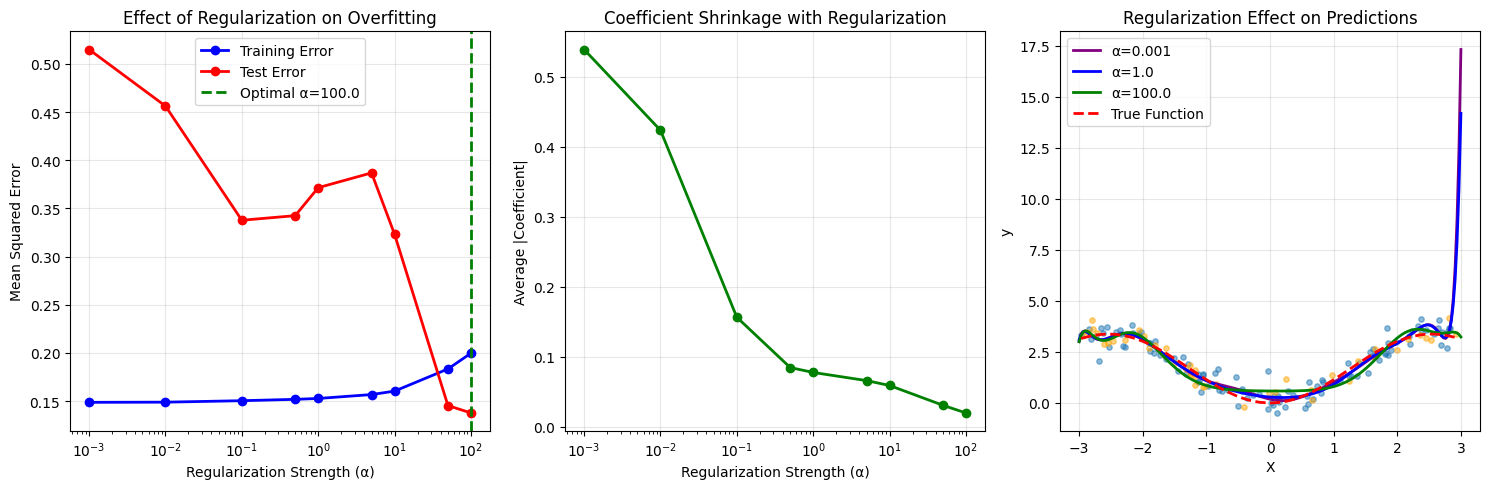

In [19]:
# Ridge regression with different regularization strengths
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
ridge_train_errors = []
ridge_test_errors = []
ridge_coefficients = []

print("\n" + "="*60)
print("RIDGE REGRESSION: EFFECT OF REGULARIZATION")
print("="*60)

for alpha in alphas:
    ridge = make_pipeline(PolynomialFeatures(degree=15), Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    
    y_train_pred = ridge.predict(X_train)
    y_test_pred = ridge.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    ridge_train_errors.append(train_mse)
    ridge_test_errors.append(test_mse)
    
    # Get coefficients
    coef = ridge.named_steps['ridge'].coef_
    ridge_coefficients.append(np.mean(np.abs(coef)))
    
    print(f"Alpha={alpha:6.3f}: Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}")

# Plot regularization effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Error vs regularization
axes[0].semilogx(alphas, ridge_train_errors, 'b-o', label='Training Error', linewidth=2)
axes[0].semilogx(alphas, ridge_test_errors, 'r-o', label='Test Error', linewidth=2)
optimal_alpha = alphas[np.argmin(ridge_test_errors)]
axes[0].axvline(x=optimal_alpha, color='green', linestyle='--', 
                label=f'Optimal α={optimal_alpha}', linewidth=2)
axes[0].set_xlabel('Regularization Strength (α)')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Effect of Regularization on Overfitting')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Coefficient magnitude
axes[1].semilogx(alphas, ridge_coefficients, 'g-o', linewidth=2)
axes[1].set_xlabel('Regularization Strength (α)')
axes[1].set_ylabel('Average |Coefficient|')
axes[1].set_title('Coefficient Shrinkage with Regularization')
axes[1].grid(True, alpha=0.3)

# Plot 3: Model predictions with different regularization
axes[2].scatter(X_train, y_train, alpha=0.5, s=15)
axes[2].scatter(X_test, y_test, alpha=0.5, s=15, color='orange')

X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
for alpha, color in zip([0.001, 1.0, 100.0], ['purple', 'blue', 'green']):
    ridge = make_pipeline(PolynomialFeatures(degree=15), Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    y_grid_pred = ridge.predict(X_grid)
    axes[2].plot(X_grid, y_grid_pred, color=color, linewidth=2, label=f'α={alpha}')

axes[2].plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
            color='red', label='True Function', linewidth=2, linestyle='--')
axes[2].set_xlabel('X')
axes[2].set_ylabel('y')
axes[2].set_title('Regularization Effect on Predictions')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  How to Detect and Fix Overfitting/Underfitting

In [ ]:
def diagnose_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Comprehensive diagnosis of a model
    """
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    gap = test_mse - train_mse
    
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    print(f"Training MSE:     {train_mse:.4f}")
    print(f"Test MSE:         {test_mse:.4f}")
    print(f"Training R²:      {train_r2:.4f}")
    print(f"Test R²:          {test_r2:.4f}")
    print(f"Generalization Gap: {gap:.4f}")
    
    # Diagnosis
    if train_mse > 0.8 and test_mse > 0.8:
        diagnosis = " UNDERFITTING (High Bias)"
        solution = "Increase model complexity, add features, use polynomial features"
    elif train_mse < 0.3 and test_mse > 0.8:
        diagnosis = " OVERFITTING (High Variance)"
        solution = "Reduce model complexity, increase regularization, get more data"
    elif train_mse < 0.3 and test_mse < 0.3:
        diagnosis = " GOOD FIT"
        solution = "Model is well-balanced"
    else:
        diagnosis = " MODERATE"
        solution = "Consider more data or slightly adjust complexity"
    
    print(f"\nDiagnosis:        {diagnosis}")
    print(f"Solution:         {solution}")
    
    return {
        'model': model_name,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gap': gap,
        'diagnosis': diagnosis,
        'solution': solution
    }

# Test all models
models_to_diagnose = [
    ('Linear Regression', LinearRegression()),
    ('Polynomial Degree 2', make_pipeline(PolynomialFeatures(2), LinearRegression())),
    ('Polynomial Degree 3', make_pipeline(PolynomialFeatures(3), LinearRegression())),
    ('Polynomial Degree 5', make_pipeline(PolynomialFeatures(5), LinearRegression())),
    ('Polynomial Degree 10', make_pipeline(PolynomialFeatures(10), LinearRegression())),
    ('Polynomial Degree 20', make_pipeline(PolynomialFeatures(20), LinearRegression())),
    ('Decision Tree Depth 3', DecisionTreeRegressor(max_depth=3, random_state=42)),
    ('Decision Tree Depth 10', DecisionTreeRegressor(max_depth=10, random_state=42)),
    ('Decision Tree Depth 20', DecisionTreeRegressor(max_depth=20, random_state=42)),
    ('Ridge α=0.1 (deg15)', make_pipeline(PolynomialFeatures(15), Ridge(alpha=0.1))),
    ('Ridge α=1.0 (deg15)', make_pipeline(PolynomialFeatures(15), Ridge(alpha=1.0))),
    ('Ridge α=10.0 (deg15)', make_pipeline(PolynomialFeatures(15), Ridge(alpha=10.0))),
]

diagnosis_results = []
for name, model in models_to_diagnose:
    result = diagnose_model(model, X_train, X_test, y_train, y_test, name)
    diagnosis_results.append(result)

# Summary table
print("\n" + "="*100)
print("SUMMARY: MODEL DIAGNOSIS")
print("="*100)
print(f"{'Model':<30} {'Train MSE':<12} {'Test MSE':<12} {'Gap':<10} {'Diagnosis':<25}")
print("-"*100)
for r in diagnosis_results:
    print(f"{r['model']:<30} {r['train_mse']:.4f}     {r['test_mse']:.4f}     {r['gap']:.4f}    {r['diagnosis']:<25}")
print("="*100)

# Plot summary
fig, ax = plt.subplots(figsize=(12, 6))
model_names = [r['model'] for r in diagnosis_results]
x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, [r['train_mse'] for r in diagnosis_results], width, 
       label='Training Error', color='blue', alpha=0.7)
ax.bar(x + width/2, [r['test_mse'] for r in diagnosis_results], width, 
       label='Test Error', color='red', alpha=0.7)

# Color bars based on diagnosis
for i, r in enumerate(diagnosis_results):
    if 'UNDERFITTING' in r['diagnosis']:
        color = 'red'
    elif 'OVERFITTING' in r['diagnosis']:
        color = 'orange'
    else:
        color = 'green'
    ax.bar(x[i], r['test_mse'], width, color=color, alpha=0.3)

ax.set_xlabel('Models')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Model Comparison: Underfitting vs Overfitting')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MODEL: Linear Regression
Training MSE:     0.1121
Test MSE:         0.1180
Training R²:      0.5515
Test R²:          0.5278
Generalization Gap: 0.0059

Diagnosis:         GOOD FIT
Solution:         Model is well-balanced

MODEL: Polynomial Degree 2
Training MSE:     0.1060
Test MSE:         0.1165
Training R²:      0.5759
Test R²:          0.5338
Generalization Gap: 0.0105

Diagnosis:         GOOD FIT
Solution:         Model is well-balanced

MODEL: Polynomial Degree 3
Training MSE:     0.0764
Test MSE:         0.1318
Training R²:      0.6943
Test R²:          0.4727
Generalization Gap: 0.0554

Diagnosis:         GOOD FIT
Solution:         Model is well-balanced


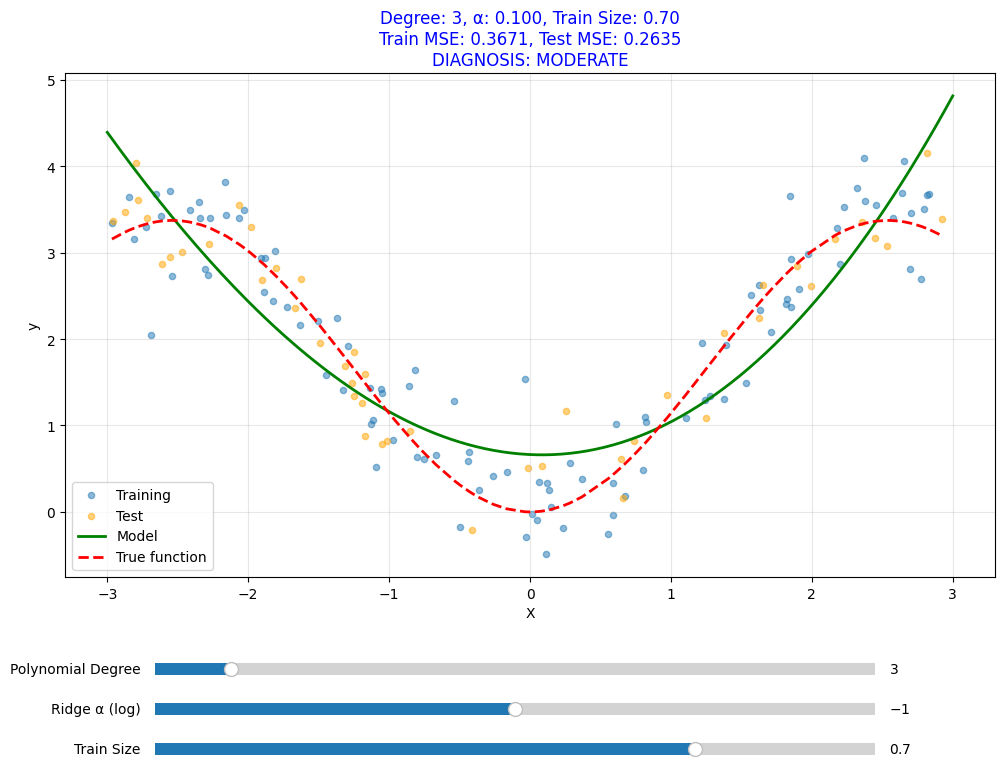

In [21]:
from matplotlib.widgets import Slider

def interactive_model_explorer():
    """
    Interactive tool to explore overfitting and underfitting
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.subplots_adjust(bottom=0.25)
    
    # Initial parameters
    degree = 3
    alpha = 0.1
    train_size = 0.7
    
    # Create sliders
    ax_degree = plt.axes([0.2, 0.12, 0.6, 0.03])
    ax_alpha = plt.axes([0.2, 0.07, 0.6, 0.03])
    ax_train_size = plt.axes([0.2, 0.02, 0.6, 0.03])
    
    slider_degree = Slider(ax_degree, 'Polynomial Degree', 1, 20, valinit=degree, valstep=1)
    slider_alpha = Slider(ax_alpha, 'Ridge α (log)', -4, 2, valinit=np.log10(alpha))
    slider_train_size = Slider(ax_train_size, 'Train Size', 0.1, 0.9, valinit=train_size)
    
    def update(val):
        ax.clear()
        degree = int(slider_degree.val)
        alpha = 10 ** slider_alpha.val
        train_size = slider_train_size.val
        
        # Split data
        X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
            X, y, test_size=1-train_size, random_state=42
        )
        
        # Create model
        if alpha > 0:
            model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
        else:
            model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        
        model.fit(X_train_sub, y_train_sub)
        
        # Predict
        X_grid = np.linspace(-3, 3, 200).reshape(-1, 1)
        y_grid_pred = model.predict(X_grid)
        
        # Plot
        ax.scatter(X_train_sub, y_train_sub, alpha=0.5, label='Training', s=20)
        ax.scatter(X_test_sub, y_test_sub, alpha=0.5, label='Test', s=20, color='orange')
        ax.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Model')
        ax.plot(X_sorted, X_sorted * np.sin(X_sorted) + 0.3 * X_sorted**2, 
                color='red', label='True function', linewidth=2, linestyle='--')
        
        # Calculate errors
        train_mse = mean_squared_error(y_train_sub, model.predict(X_train_sub))
        test_mse = mean_squared_error(y_test_sub, model.predict(X_test_sub))
        
        # Diagnosis
        if train_mse > 0.8 and test_mse > 0.8:
            diagnosis = "UNDERFITTING"
            color = 'red'
        elif train_mse < 0.3 and test_mse > 0.8:
            diagnosis = "OVERFITTING"
            color = 'orange'
        elif train_mse < 0.3 and test_mse < 0.3:
            diagnosis = "GOOD FIT"
            color = 'green'
        else:
            diagnosis = "MODERATE"
            color = 'blue'
        
        ax.set_xlabel('X')
        ax.set_ylabel('y')
        ax.set_title(f'Degree: {degree}, α: {alpha:.3f}, Train Size: {train_size:.2f}\n'
                    f'Train MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}\n'
                    f'DIAGNOSIS: {diagnosis}', color=color)
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.canvas.draw_idle()
    
    slider_degree.on_changed(update)
    slider_alpha.on_changed(update)
    slider_train_size.on_changed(update)
    update(None)
    plt.show()


interactive_model_explorer()

>1, train: 0.869, test: 0.854
>2, train: 0.869, test: 0.854
>3, train: 0.882, test: 0.865
>4, train: 0.900, test: 0.886
>5, train: 0.906, test: 0.888
>6, train: 0.916, test: 0.897
>7, train: 0.929, test: 0.893
>8, train: 0.937, test: 0.878
>9, train: 0.947, test: 0.880
>10, train: 0.956, test: 0.872
>11, train: 0.966, test: 0.867
>12, train: 0.974, test: 0.867
>13, train: 0.983, test: 0.867
>14, train: 0.987, test: 0.861
>15, train: 0.991, test: 0.862
>16, train: 0.993, test: 0.854
>17, train: 0.995, test: 0.855
>18, train: 0.996, test: 0.857
>19, train: 0.998, test: 0.860
>20, train: 0.999, test: 0.850


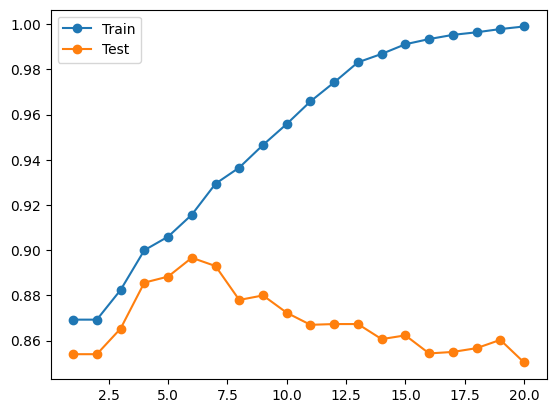

In [22]:
# evaluate decision tree performance on train and test sets with different tree depths
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot
# create dataset
X, y = make_classification(n_samples=10000, n_features=20, random_state=4)
# split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
# define lists to collect scores
train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 21)]
# evaluate a decision tree for each depth
for i in values:
	# configure the model
	model = DecisionTreeClassifier(max_depth=i)
	# fit model on the training dataset
	model.fit(X_train, y_train)
	# evaluate on the train dataset
	train_yhat = model.predict(X_train)
	train_acc = accuracy_score(y_train, train_yhat)
	train_scores.append(train_acc)
	# evaluate on the test dataset
	test_yhat = model.predict(X_test)
	test_acc = accuracy_score(y_test, test_yhat)
	test_scores.append(test_acc)
	# summarize progress
	print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))
# plot of train and test scores vs tree depth
pyplot.plot(values, train_scores, '-o', label='Train')
pyplot.plot(values, test_scores, '-o', label='Test')
pyplot.legend()
pyplot.show()